# Ch11 - Rainbow DQN 改进技巧

Double DQN + Dueling Network + Prioritized Experience Replay 三项核心改进。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random
from collections import deque, defaultdict

# 中文字体配置
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | 设备: {device} | Gymnasium: {gym.__version__}')


PyTorch: 2.13.0+cpu | 设备: cpu | Gymnasium: 1.3.0


## 11.1 DQN 的三大问题

1. **Q 值过估**：max 操作放大估计误差 → Double DQN
2. **V 与 A 不分离**：Q 同时编码'状态好坏'与'动作优势' → Dueling Network
3. **均匀采样浪费**：高 TD 误差样本被低优先级处理 → PER

## 11.2 Double DQN

把'选动作'和'估价'分开：
$$Q_{target} = r + \gamma Q_{target}(s', \arg\max_{a'} Q_{policy}(s', a'))$$

用 policy_net 选动作（'我认为哪个动作好'），用 target_net 估价（'客观上值多少'）。

## 11.3 Dueling Network

Q(s,a) = V(s) + A(s,a) - mean(A(s,·))

V(s) 评估'状态本身的好坏'，A(s,a) 评估'动作相对平均的优势'。这种分解让网络更高效——许多状态下动作选择无关紧要，只需更新 V。

## 11.4 Prioritized Experience Replay (PER)

按 |TD 误差| 比例采样：$P(i) = p_i^\alpha / \sum_k p_k^\alpha$

用重要性采样权重修正偏差：$w_i = (1/(N \cdot P(i)))^\beta$

β 从 0.4 线性退火到 1.0（最终完全无偏）。

In [2]:
import torch.optim as optim

class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.feature = nn.Sequential(nn.Linear(state_dim, hidden), nn.ReLU())
        self.value = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
        self.advantage = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, action_dim))
    def forward(self, x):
        h = self.feature(x)
        v = self.value(h)
        a = self.advantage(h)
        return v + (a - a.mean(dim=1, keepdim=True))


class PrioritizedReplayBuffer:
    def __init__(self, capacity=10_000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = [None] * capacity
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0
    def push(self, *args, prio=1.0):
        self.buffer[self.pos] = args
        self.priorities[self.pos] = prio
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    def sample(self, batch_size, beta=0.4):
        probs = self.priorities[:self.size] ** self.alpha
        probs = probs / probs.sum()
        idx = np.random.choice(self.size, batch_size, p=probs)
        samples = [self.buffer[i] for i in idx]
        weights = (self.size * probs[idx]) ** (-beta)
        weights = weights / weights.max()
        return idx, samples, torch.tensor(weights, dtype=torch.float32)
    def update_priorities(self, idx, priorities):
        for i, p in zip(idx, priorities):
            self.priorities[i] = abs(p) + 1e-5

print('Dueling Q-Network + PER 定义完成 ✓')

Dueling Q-Network + PER 定义完成 ✓


In [3]:
class DoubleDQNAgent:
    """Double DQN + Dueling + PER。"""
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 buffer_size=10_000, batch_size=64, target_sync=10,
                 alpha=0.6, beta=0.4, beta_frames=10_000):
        self.device = device
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_sync = target_sync
        self.beta = beta
        self.beta_frames = beta_frames
        self.frame = 0

        self.policy_net = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_net = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

        self.buffer = PrioritizedReplayBuffer(buffer_size, alpha=alpha)
        self.epsilon = 0.05

    def act(self, state, eval_mode=False):
        if not eval_mode and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            return int(self.policy_net(s).argmax(dim=1).item())

    def learn(self):
        if self.buffer.size < self.batch_size: return None
        beta = min(1.0, self.beta + self.frame * (1 - self.beta) / self.beta_frames)
        idx, samples, weights = self.buffer.sample(self.batch_size, beta)
        weights = weights.to(device)

        s = torch.as_tensor(np.array([x[0] for x in samples]), dtype=torch.float32, device=device)
        a = torch.as_tensor([x[1] for x in samples], dtype=torch.long, device=device).unsqueeze(1)
        r = torch.as_tensor([x[2] for x in samples], dtype=torch.float32, device=device)
        s_next = torch.as_tensor(np.array([x[3] for x in samples]), dtype=torch.float32, device=device)
        done = torch.as_tensor([x[4] for x in samples], dtype=torch.float32, device=device)

        q_sa = self.policy_net(s).gather(1, a).squeeze(1)
        with torch.no_grad():
            a_next = self.policy_net(s_next).argmax(dim=1, keepdim=True)
            q_next = self.target_net(s_next).gather(1, a_next).squeeze(1)
            q_target = r + self.gamma * q_next * (1 - done)

        td_error = (q_sa - q_target).detach().cpu().numpy()
        self.buffer.update_priorities(idx, td_error)

        loss = (weights * (q_sa - q_target) ** 2).mean()
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()
        self.frame += 1
        return loss.item()

env = gym.make('CartPole-v1')
agent = DoubleDQNAgent(env.observation_space.shape[0], env.action_space.n)
print('Double DQN + Dueling + PER Agent 创建完成 ✓')

Double DQN + Dueling + PER Agent 创建完成 ✓


## 11.5 训练循环

In [4]:
random.seed(42); np.random.seed(42); torch.manual_seed(42)
episodes = 500
max_steps = 500
rewards = []

for ep in range(episodes):
    s, _ = env.reset(seed=42 + ep)
    total_r = 0
    for t in range(max_steps):
        a = agent.act(s)
        s_next, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        r_shaped = -10.0 if terminated and t < max_steps - 1 else r
        agent.buffer.push(s, a, r_shaped, s_next, done)
        s = s_next
        total_r += r
        agent.learn()
        if done: break
    if (ep + 1) % agent.target_sync == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())
    rewards.append(total_r)
    if (ep + 1) % 20 == 0:
        print(f'ep {ep+1:3d} | reward={total_r:5.1f} | avg20={np.mean(rewards[-20:]):5.1f}')

ep  20 | reward=  9.0 | avg20= 12.2
ep  40 | reward= 83.0 | avg20= 29.5
ep  60 | reward=115.0 | avg20=127.6
ep  80 | reward=252.0 | avg20=237.8
ep 100 | reward=106.0 | avg20=136.9
ep 120 | reward=433.0 | avg20=192.2
ep 140 | reward=118.0 | avg20=131.8
ep 160 | reward=116.0 | avg20=122.2
ep 180 | reward=119.0 | avg20=119.5
ep 200 | reward=122.0 | avg20=121.2
ep 220 | reward=114.0 | avg20=111.2
ep 240 | reward=119.0 | avg20=119.0
ep 260 | reward=129.0 | avg20=115.8
ep 280 | reward=122.0 | avg20=120.2
ep 300 | reward=127.0 | avg20=119.2
ep 320 | reward=145.0 | avg20=135.8
ep 340 | reward=126.0 | avg20=130.5
ep 360 | reward=129.0 | avg20=129.1
ep 380 | reward=131.0 | avg20=120.3
ep 400 | reward= 91.0 | avg20=124.0
ep 420 | reward=150.0 | avg20=146.1
ep 440 | reward=149.0 | avg20=146.3
ep 460 | reward=114.0 | avg20=131.9
ep 480 | reward=159.0 | avg20=140.9
ep 500 | reward=126.0 | avg20=118.5


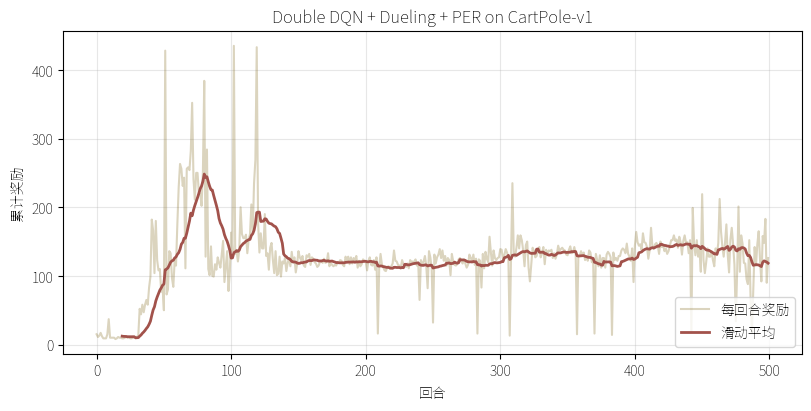

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(rewards, alpha=0.3, color='#887129', label='每回合奖励')
if len(rewards) >= 20:
    ma = np.convolve(rewards, np.ones(20)/20, mode='valid')
    ax.plot(range(19, len(rewards)), ma, color='#a2524b', linewidth=2, label='滑动平均')
ax.set_xlabel('回合'); ax.set_ylabel('累计奖励')
ax.set_title('Double DQN + Dueling + PER on CartPole-v1')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()

## 11.6 小结

**性价比排序**（基于 Atari 实验）：
1. Double DQN（必选，改 1 行代码）
2. Dueling Network（推荐，改网络结构）
3. PER（推荐，改 buffer）
4. Multi-step Returns（可选）
5. NoisyNet（可选，替代 ε-greedy）
6. C51（研究用，分布化 RL）

下一章：**RLHF**——用 RL 微调大语言模型，ChatGPT 的核心技术。